In [2]:
import pandas as pd 
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Dataset Preparation

In [3]:
import re
import nltk
from nltk.util import pr
stemmer = nltk.SnowballStemmer("english")
from nltk.corpus import stopwords
import string
stopword = set(stopwords.words("english"))

In [4]:
df_og = pd.read_csv("../datasets/twitter_data.csv")
df_og.head()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [5]:
# Labels column for the dataset 
df_og['labels'] = df_og['class'].map({0: "Hate Speech Detected", 1: "Offensive Language Detected", 2:"No hate or offensive speech"})
df_og.head()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet,labels
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...,No hate or offensive speech
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,Offensive Language Detected
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,Offensive Language Detected
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,Offensive Language Detected
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,Offensive Language Detected


In [6]:
df = df_og[["tweet", "labels"]]
df.head()

,tweet,labels
0,!!! RT @mayasolovely: As a woman you shouldn't...,No hate or offensive speech
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,Offensive Language Detected
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,Offensive Language Detected
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,Offensive Language Detected
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,Offensive Language Detected


In [7]:
# Clean the tweet text 
def clean(text):
    text = str(text).lower()  # Convert to lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)  # Remove URLs
    text = re.sub(r'\@\w+|\#', '', text)  # Remove mentions and hashtags
    text = re.sub(r'[^A-Za-z0-9\s]', '', text)  # Remove special characters
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    text = re.sub(r'\n', '', text)  # Remove newlines
    text = re.sub(r'\w*\d\w*', '', text)  # Remove words containing digits
    text = [word for word in text.split() if word not in stopword]  # Remove stopwords
    text = " ".join(text)  # Join the words back into a single string
    return text

In [8]:
df["tweet"] = df["tweet"].apply(clean)
df.head()

/tmp/ipykernel_23320/2787220285.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["tweet"] = df["tweet"].apply(clean)


,tweet,labels
0,rt woman shouldnt complain cleaning house amp ...,No hate or offensive speech
1,rt boy dats coldtyga dwn bad cuffin dat hoe place,Offensive Language Detected
2,rt dawg rt ever fuck bitch start cry confused ...,Offensive Language Detected
3,rt look like tranny,Offensive Language Detected
4,rt shit hear might true might faker bitch told ya,Offensive Language Detected


In [9]:
x = np.array(df["tweet"])
y = np.array(df["labels"])

In [10]:

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.33, random_state = 42)

## Decision Tree Model

In [11]:
cv_dt = CountVectorizer()
X_train_transformed_dt = cv_dt.fit_transform(X_train)

In [12]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train_transformed_dt, y_train)

DecisionTreeClassifier()

In [13]:
X_test_transformed_dt = cv_dt.transform(X_test)
y_pred_dt = dt_model.predict(X_test_transformed_dt)

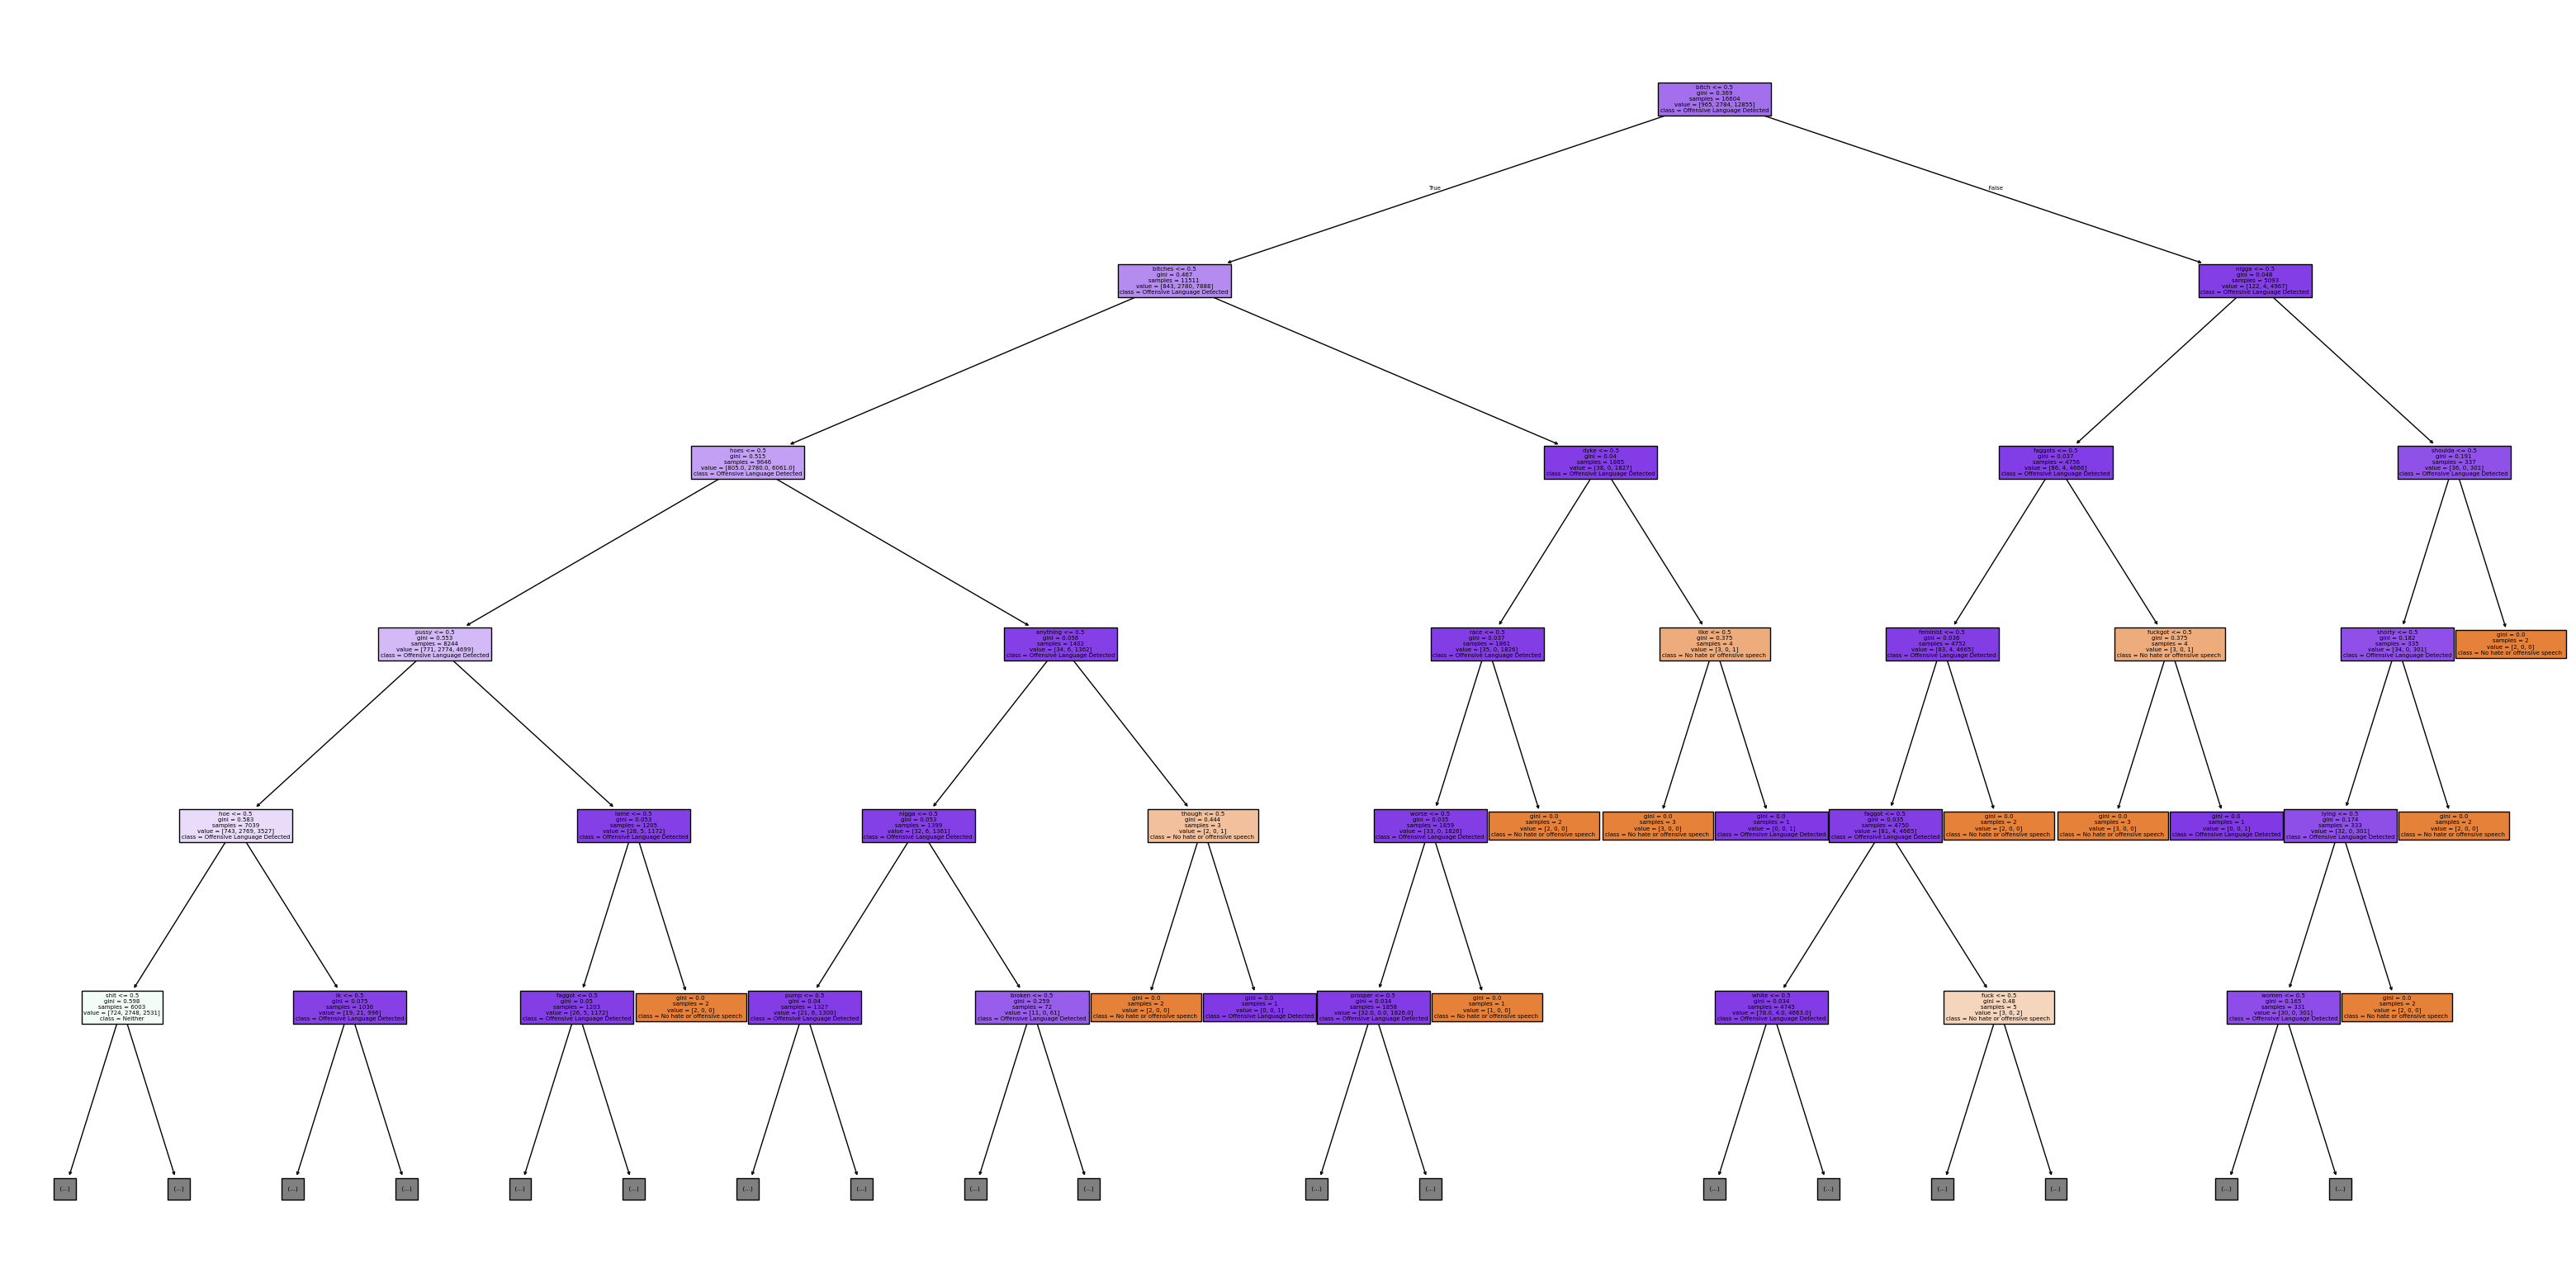

In [17]:
import matplotlib.pyplot as plt

# Visualize the tree
plt.figure(figsize=(40, 20))
plot_tree(dt_model, filled=True, feature_names=cv_dt.get_feature_names_out(), class_names=['No hate or offensive speech ', 'Neither', 'Offensive Language Detected'], max_depth=5)
plt.show()

In [18]:
tree_depth = dt_model.get_depth()
print(f"The depth of the decision tree is: {tree_depth}")

The depth of the decision tree is: 500


In [30]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree Classification Report:\n", classification_report(y_test, y_pred_dt))
print("Decision Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8628194155764763
Decision Tree Classification Report:
                              precision    recall  f1-score   support

       Hate Speech Detected       0.34      0.33      0.34       465
No hate or offensive speech       0.82      0.74      0.78      1379
Offensive Language Detected       0.91      0.93      0.92      6335

                   accuracy                           0.86      8179
                  macro avg       0.69      0.67      0.68      8179
               weighted avg       0.86      0.86      0.86      8179

Decision Tree Confusion Matrix:
 [[ 155   36  274]
 [  38 1026  315]
 [ 264  195 5876]]


In [34]:
test_data = "you are a good"
df = cv_dt.transform([test_data]).toarray()
print(dt_model.predict(df))

['No hate or offensive speech']


In [18]:
# Save the model
import joblib
joblib.dump(model, 'decision_tree_model.pkl')
joblib.dump(cv, 'count_vectorizer.pkl')

['count_vectorizer.pkl']

## Naive Bayes 


In [10]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer

In [11]:
label_mapping = {
    0: "Hate Speech Detected",
    1: "Offensive Language Detected",
    2: "No hate or offensive speech"
}

In [12]:
df = df_og[['tweet', 'class']]
df.head()

,tweet,class
0,!!! RT @mayasolovely: As a woman you shouldn't...,2
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,1
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,1
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,1
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,1


In [13]:
X_train, X_test, y_train, y_test = train_test_split(df['tweet'], df['class'], test_size=0.2, random_state=42)

In [14]:
# Initialize CountVectorizer for Naive Bayes
tfidf_nb = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))

In [15]:
X_train_tfidf_nb = tfidf_nb.fit_transform(X_train)
X_test_tfidf_nb = tfidf_nb.transform(X_test)

In [16]:
# Train Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf_nb, y_train)

MultinomialNB()

In [17]:
y_pred = nb_model.predict(X_test_tfidf_nb)

In [18]:
accuracy = accuracy_score(y_test, y_pred)
print("Naive Bayes Accuracy:", accuracy)
print("\nNaive Bayes Classification Report:\n", classification_report(y_test, y_pred, target_names=label_mapping.values()))
print("\nNaive Bayes Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Naive Bayes Accuracy: 0.782126286060117

Naive Bayes Classification Report:
                              precision    recall  f1-score   support

       Hate Speech Detected       0.00      0.00      0.00       290
Offensive Language Detected       0.78      1.00      0.88      3832
No hate or offensive speech       0.98      0.05      0.10       835

                   accuracy                           0.78      4957
                  macro avg       0.59      0.35      0.33      4957
               weighted avg       0.77      0.78      0.69      4957


Naive Bayes Confusion Matrix:
 [[   0  289    1]
 [   0 3832    0]
 [   0  790   45]]


/home/mavis021/Documents/fuse/env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mavis021/Documents/fuse/env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mavis021/Documents/fuse/env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

In [19]:
test_data = "you are a good"
test_data_tfidf = tfidf_nb.transform([test_data])
predicted_class = nb_model.predict(test_data_tfidf)
predicted_label = label_mapping[predicted_class[0]]
print(f"\nPredicted Label for new data: {predicted_label}")


Predicted Label for new data: Offensive Language Detected


## Logistic Regression

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight

In [72]:
label_mapping = {
    0: "Hate Speech Detected",
    1: "Offensive Language Detected",
    2: "No hate or offensive speech"
}

In [56]:
df = df_og[['tweet', 'class']]
df.head()

,tweet,class
0,!!! RT @mayasolovely: As a woman you shouldn't...,2
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,1
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,1
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,1
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,1


In [57]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(df['tweet'], df['class'], test_size=0.2, random_state=42)

In [58]:
# Use TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [59]:
# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

In [60]:
# Use Logistic Regression with class weights
logistic_model = LogisticRegression(class_weight=class_weight_dict, max_iter=1000)
logistic_model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight={0: 5.797076023391813, 1: 0.4303077657681122,
                                 2: 1.9857772435897436},
                   max_iter=1000)

In [64]:
y_pred = logistic_model.predict(X_test_tfidf)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Logistic Regression Classification Report:\n", classification_report(y_test, y_pred, target_names=label_mapping.keys()))

Logistic Regression Accuracy: 0.8737139398829937
Logistic Regression Classification Report:
                              precision    recall  f1-score   support

       Hate Speech Detected       0.37      0.54      0.44       290
Offensive Language Detected       0.96      0.89      0.92      3832
No hate or offensive speech       0.77      0.91      0.84       835

                   accuracy                           0.87      4957
                  macro avg       0.70      0.78      0.73      4957
               weighted avg       0.90      0.87      0.88      4957



In [94]:

test_data = "you stupid"
test_data_transformed = tfidf.transform([test_data])
predicted_class = logistic_model.predict(test_data_transformed)

In [95]:
predicted_label = label_mapping[predicted_class[0]]

print(f"Predicted Class: {predicted_class[0]}")
print(f"Predicted Label: {predicted_label}")

Predicted Class: 0
Predicted Label: Hate Speech Detected
